In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/lerak/OneDrive/Desktop/bank_churn_analysis/data/raw/Bank_Customer_Churn_Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


Набор данных не имеет пропусков. Колонки country и gender являются категориальными, большинство классических алгоритмов требуют числовой формат, поэтому их следует закодировать через One-Hot Encoding. Колонка customer_id необходимо удалить, так как она является идентификатором и не несёт информации для модели. Целевая переменная churn означает, ушёл клиент или остался.

In [6]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Медиана баланса 97 198 выше среднего 76 486, распределение смещено влево. 25-й процентиль равен 0, у значительной части клиентов баланс нулевой. Среднее значение churn 0.2037, то есть 20.37% клиентов ушли, дисбаланс классов 80 на 20. Следует проверить причину нулевых балансов и наличие выбросов.

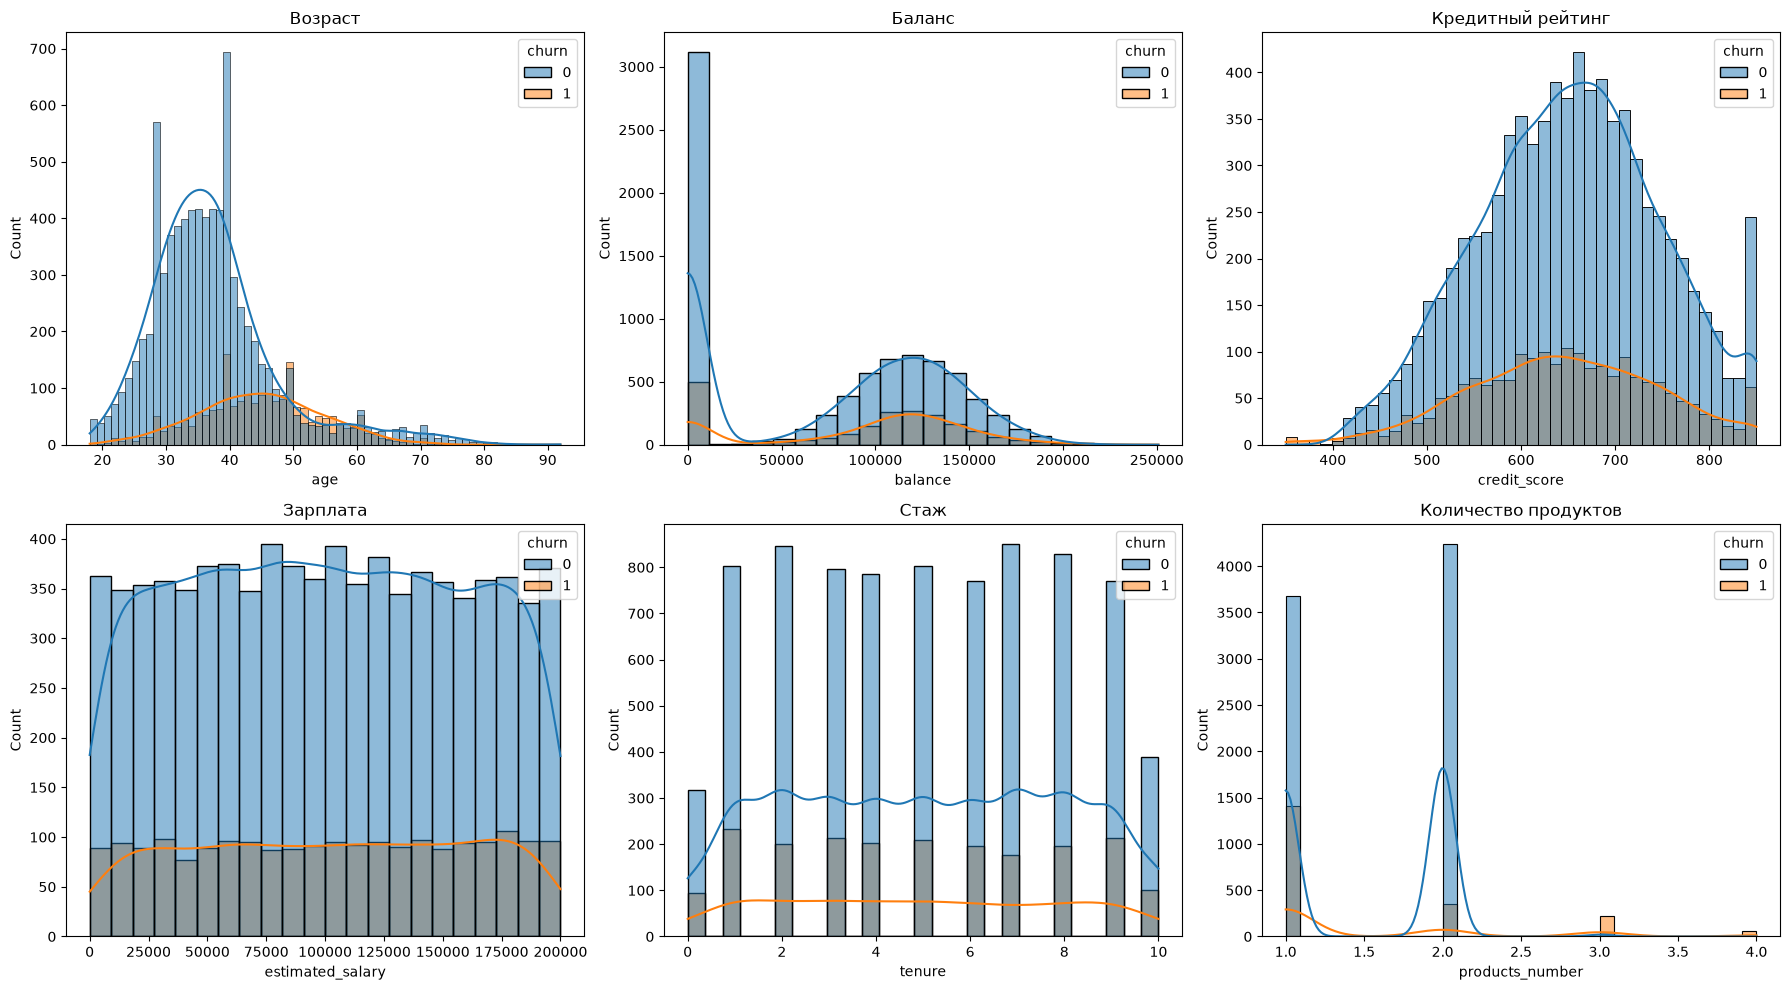

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(data=df, x='age', hue='churn', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Возраст')

sns.histplot(data=df, x='balance', hue='churn', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Баланс')

sns.histplot(data=df, x='credit_score', hue='churn', kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Кредитный рейтинг')

sns.histplot(data=df, x='estimated_salary', hue='churn', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Зарплата')

sns.histplot(data=df, x='tenure', hue='churn', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Стаж')

sns.histplot(data=df, x='products_number', hue='churn', kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Количество продуктов')

plt.tight_layout()
plt.savefig('../images/numeric_features.png', dpi=100, bbox_inches='tight')
plt.show()

Ушедшие клиенты старше, пик оттока приходится на 40–50 лет. У большинства клиентов баланс равен нулю, при этом у клиентов с высоким балансом отток выше. Кредитный рейтинг существенной разницы между ушедшими и оставшимися не показывает, как и зарплата, распределение которой равномерное. Клиенты со стажем 1–9 лет уходят примерно одинаково. Клиенты с 1 продуктом уходят чаще, с 3–4 продуктами уходят почти все.

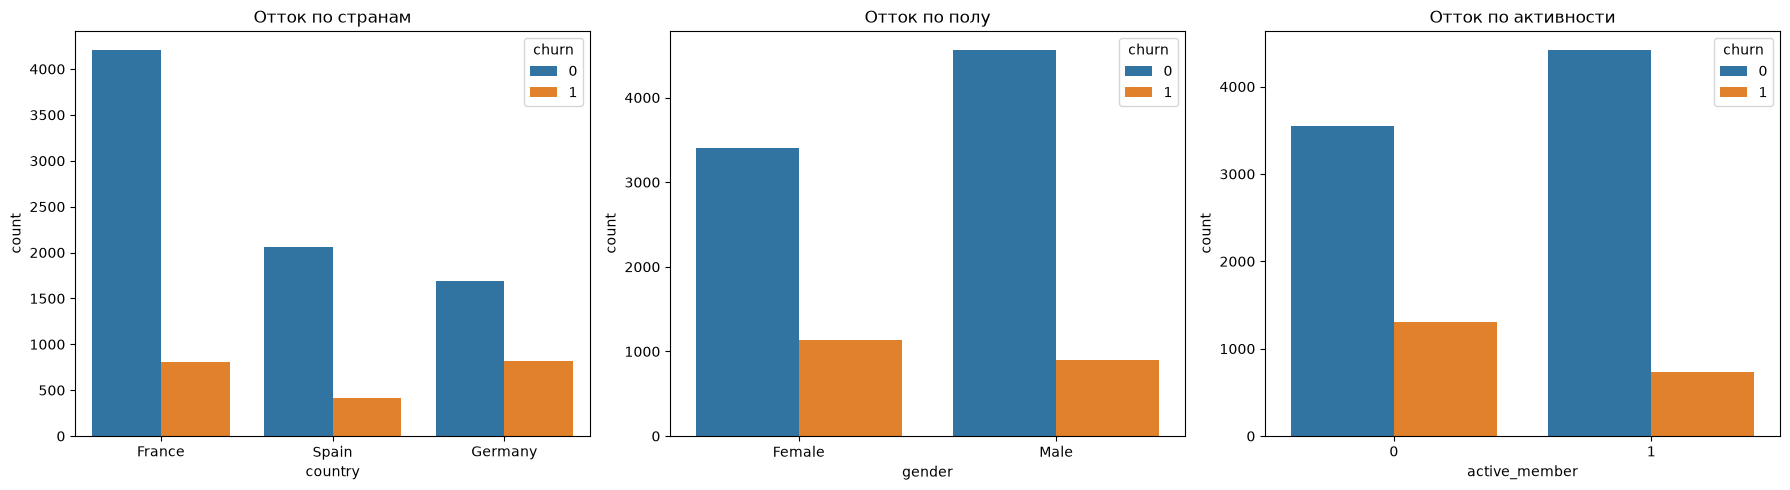

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='country', hue='churn', ax=axes[0])
axes[0].set_title('Отток по странам')

sns.countplot(data=df, x='gender', hue='churn', ax=axes[1])
axes[1].set_title('Отток по полу')

sns.countplot(data=df, x='active_member', hue='churn', ax=axes[2])
axes[2].set_title('Отток по активности')

plt.tight_layout()
plt.savefig('../images/categorical_features.png', dpi=100, bbox_inches='tight')
plt.show()

В Германии доля оттока выше, чем во Франции и Испании. Женщины уходят чаще мужчин. Неактивные клиенты уходят чаще активных.

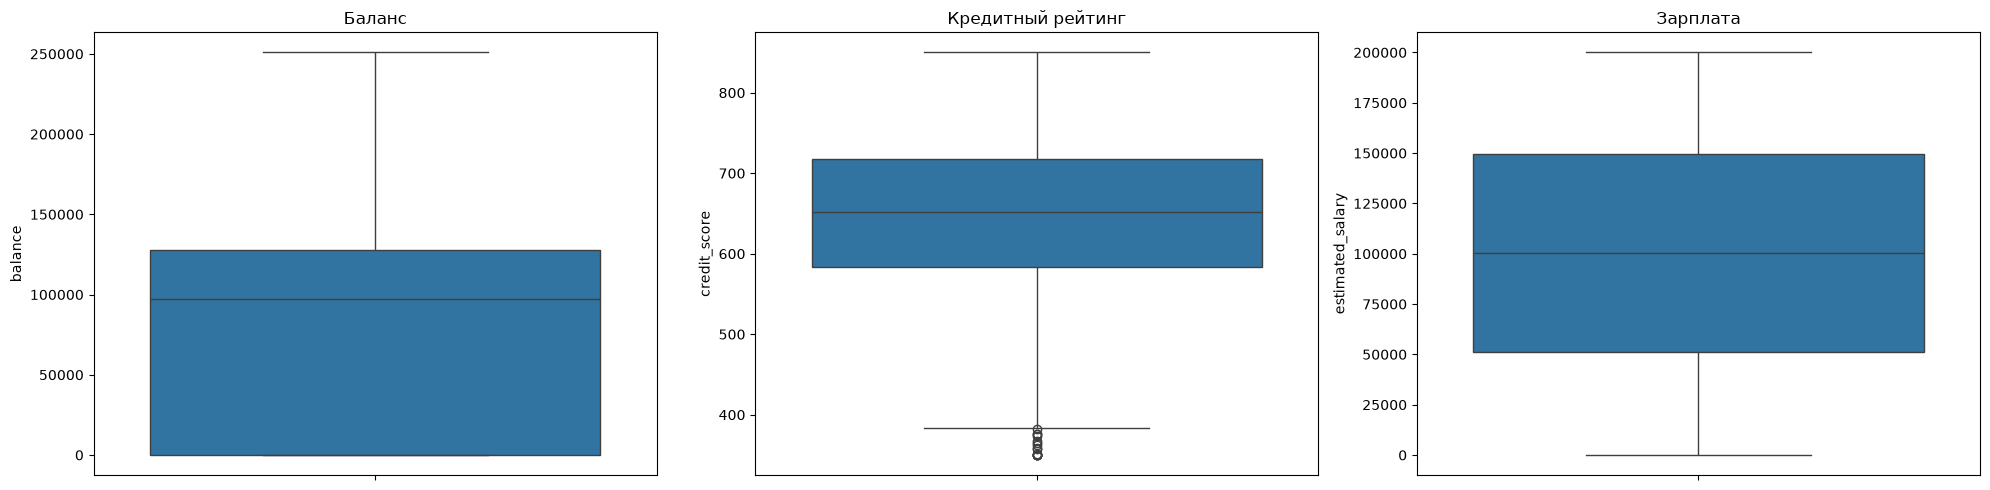

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(y=df['balance'], ax=axes[0])
axes[0].set_title('Баланс')

sns.boxplot(y=df['credit_score'], ax=axes[1])
axes[1].set_title('Кредитный рейтинг')

sns.boxplot(y=df['estimated_salary'], ax=axes[2])
axes[2].set_title('Зарплата')

plt.tight_layout()
plt.savefig('../images/outliers.png', dpi=100, bbox_inches='tight')
plt.show()

В балансе много нулевых значений, выбросов выше верхней границы нет. В кредитном рейтинге и зарплате аномалий не обнаружено. Бинарные признаки и признаки с ограниченным диапазоном не проверялись, так как выбросы в них невозможны.

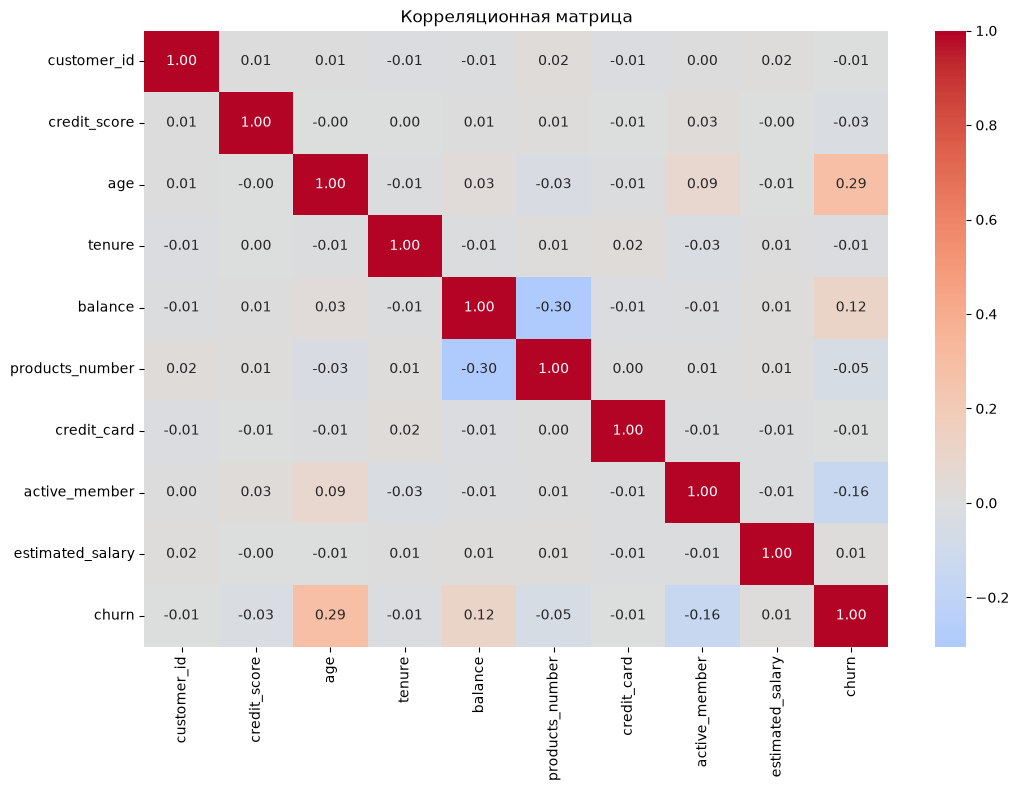

In [16]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.savefig('../images/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
Наибольшая корреляция с churn наблюдается у возраста. Остальные признаки имеют слабую корреляцию.